# Analyses for "Invisible Failures in Human–AI Interactions"

In [2]:
from datasets import load_dataset
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.metrics import cohen_kappa_score

import analysis_utils
from analysis_utils import FIGURE_OUTPUT_DIRNAME, DATA_DIRNAME

In [3]:
plt.style.use("invisible_failures.mplstyle")

In [4]:
ANTHROPIC_COLOR = "#D4A574"
OPENAI_COLOR = "#2F4F4F"
OUR_COLOR = '#7760FB'

## Raw WildChat

In [4]:
wildchat = load_dataset("allenai/WildChat-1M")

In [5]:
def count_wildchat_en():    
    lang = wildchat['train']['language']
    count = 0
    for i in range(len(lang)):
        count += (lang[i] == "English")
    return count

In [6]:
# count_wildchat_en() # 478498

## Main dataset

In [15]:
df = pd.read_json(
    os.path.join(DATA_DIRNAME, "wildchat_annotations_opus_v2.json.gz")
).set_index('conversation_id')

## Archetype formatting

In [16]:
df["archetype_tags"] = df.archetypes.apply(analysis_utils.get_archetype_tags)

In [17]:
# The anomalous cases tagged with an archetype despite manifesting a
# visible failure:

visible = df[df.failure_visibility == "visible"]
visible_archs = pd.Series([a for vals in visible.archetype_tags for a in vals]).value_counts()

In [18]:
# Number of anomalous cases:

visible.shape[0]

7632

In [19]:
visible_archs / visible_archs.sum()

The partial recovery         0.312938
The walkaway                 0.298590
The death spiral             0.138866
The confidence trap          0.105366
The silent mismatch          0.097908
The drift                    0.029581
The mystery failure          0.011440
The contradiction unravel    0.005309
Name: count, dtype: float64

In [20]:
# Here we make the decision to prioritize the `failure_visibility` 
# category and ignore the archetypes assigned to such cases:

visible_archetype_name = "Visible failure"

df["archetype_tags"] = df.apply(
    lambda row: [visible_archetype_name] if row.failure_visibility == "visible" else row.archetype_tags, 
    axis=1)

## Failure distribution

In [21]:
visdist = df.failure_visibility.value_counts()

In [22]:
visdist

failure_visibility
invisible    49368
none         37443
visible       7632
mixed         5557
Name: count, dtype: int64

In [23]:
fail_df = df[df.failure_visibility != "none"]

In [24]:
# Transcripts tagged with at least one kind of failure:

fail_df.shape[0]

62557

In [25]:
# Percentage of failures

fail_df.shape[0] / df.shape[0]

0.62557

In [26]:
# Percentage of failures that are invisible:

failvisdist = fail_df.failure_visibility.value_counts()
failvisdist.name = "Counts"

failvisdist_per = failvisdist / failvisdist.sum()
failvisdist_per.name = "Percent"

pd.concat((failvisdist, failvisdist_per), axis=1).round(2)

,Counts,Percent
failure_visibility,,
invisible,49368,0.79
visible,7632,0.12
mixed,5557,0.09


## Domains

In [27]:
df.primary_vertical.value_counts().shape

(52,)

In [28]:
df.secondary_vertical.value_counts().shape

(84,)

In [29]:
def primary_domain_plot(df, output_filename="primary_vertical.pdf"):
    dist = df.primary_vertical.value_counts()
    ax = dist.sort_values(ascending=True).plot.barh(figsize=(8, 15), logx=False, color="#666666")
    ax.bar_label(ax.containers[0], fmt="{:,.0f}", label_type='edge', fontsize=6)
    ax.set_ylabel("")
    ax.set_xlabel("Transcripts")
    ax.grid(axis='y')
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

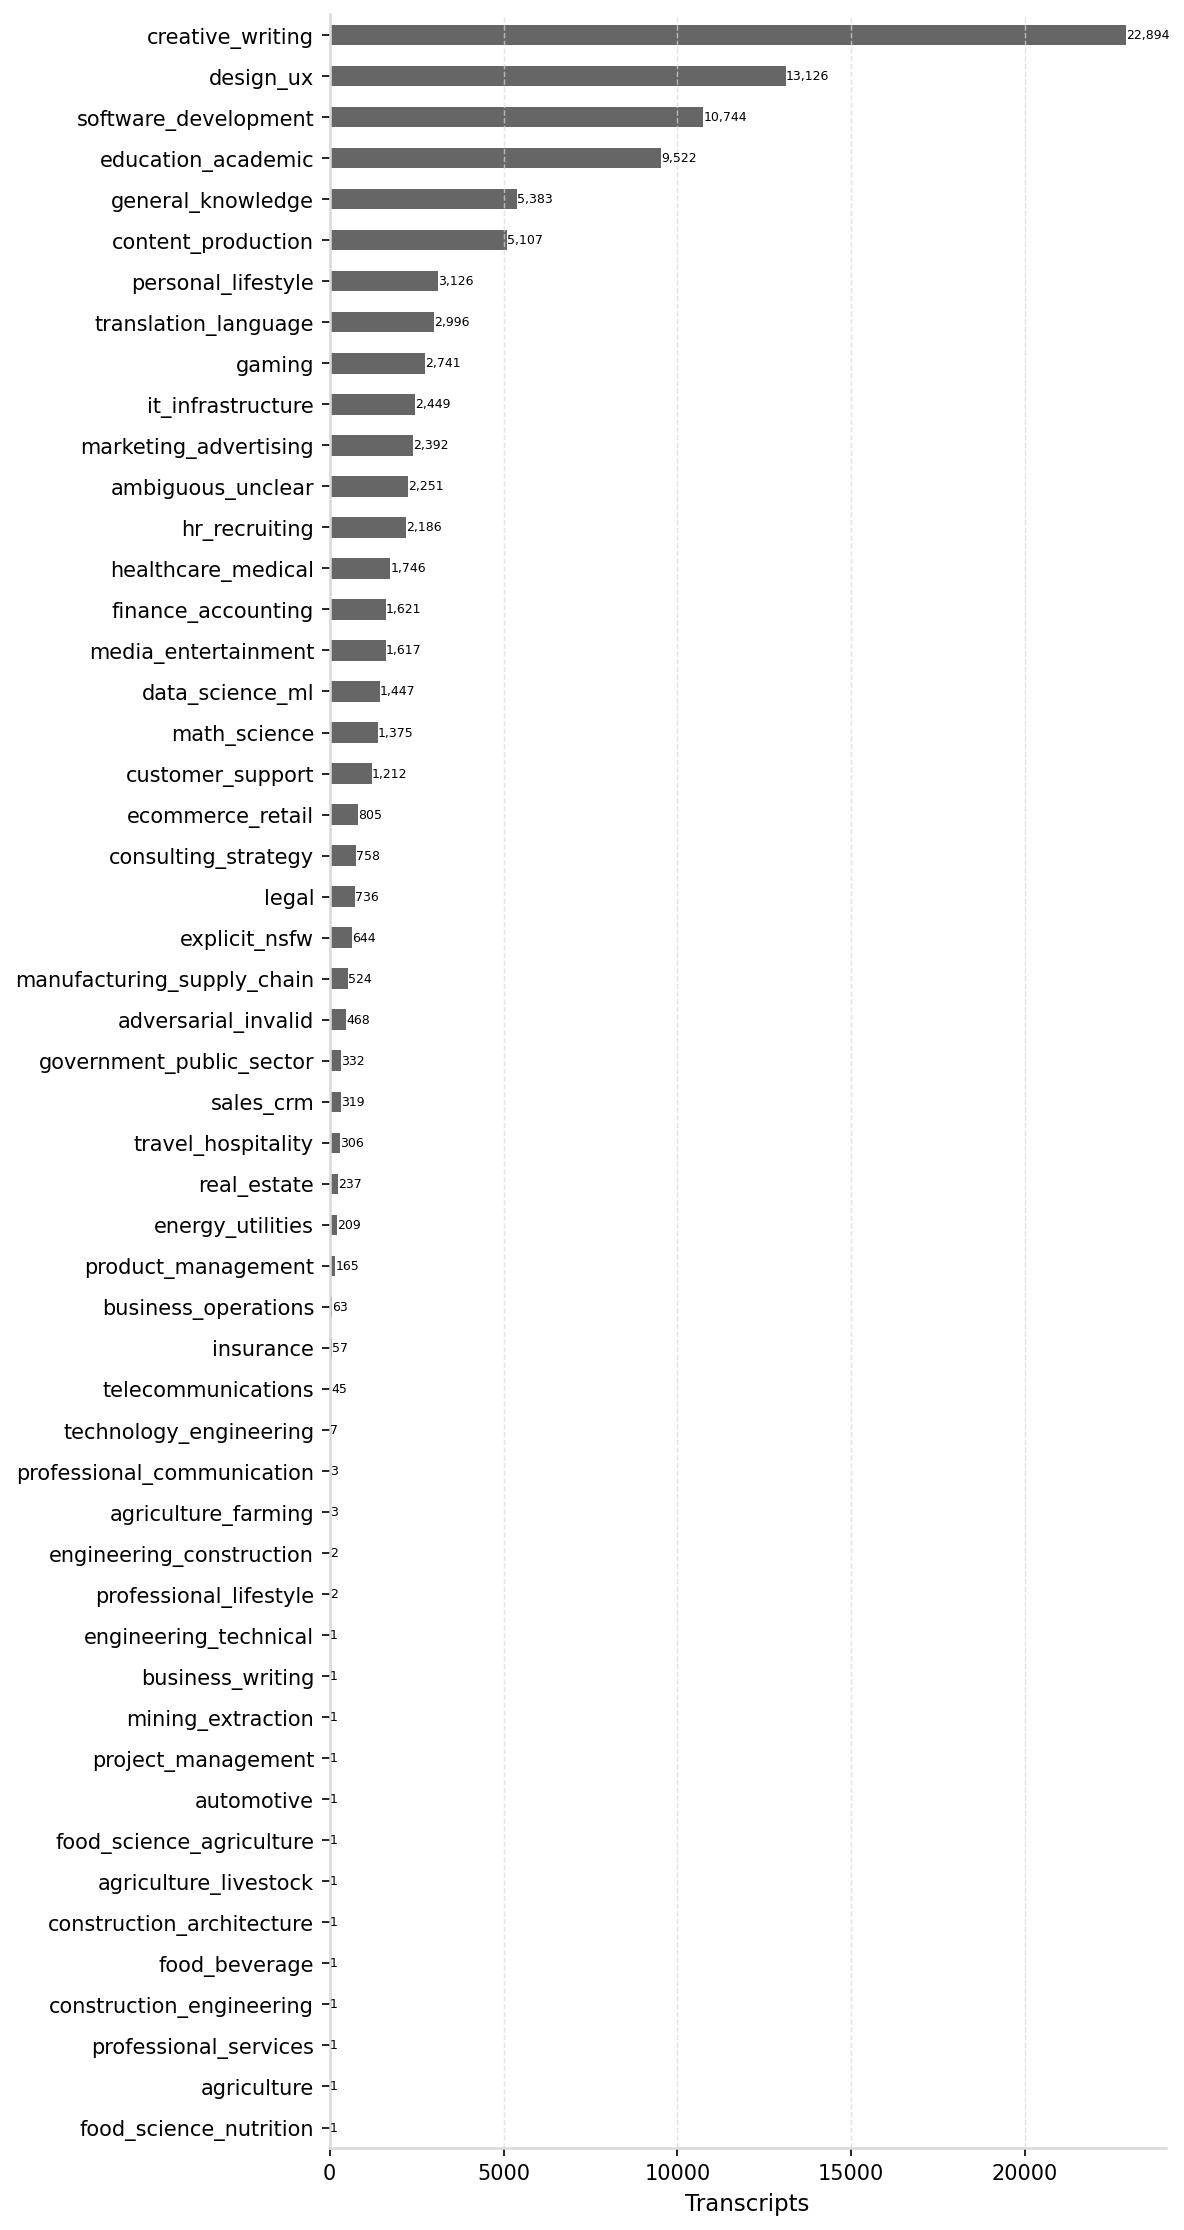

In [30]:
primary_domain_plot(df)

## Turn distribution

In [31]:
def turn_dist_plot(df, output_filename="turns.pdf"):
    dist = df.turns.value_counts()
    ax = dist.plot.bar(logy=False, figsize=(12, 5), color="#E6AB02")

    total = dist.sum()

    for patch in ax.patches:
        count = int(patch.get_height())
        pct = count / total * 100
        x_center = patch.get_x() + patch.get_width() / 10
        x_pos = patch.get_height()
        if pct > 2:
            ax.text(x_center, x_pos + 1000, f"{count:,}; {pct:.1f}%", va="bottom", fontsize=8, rotation=90)
        else:
            ax.text(x_center, x_pos + 1000, f"{count:,}", va="bottom", fontsize=8, rotation=90)
    ax.tick_params(axis='x', labelrotation=0, labelsize=8)
    ax.set_xlabel("User turns")
    ax.set_ylabel("Transcripts")
    ax.grid(axis='y')
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

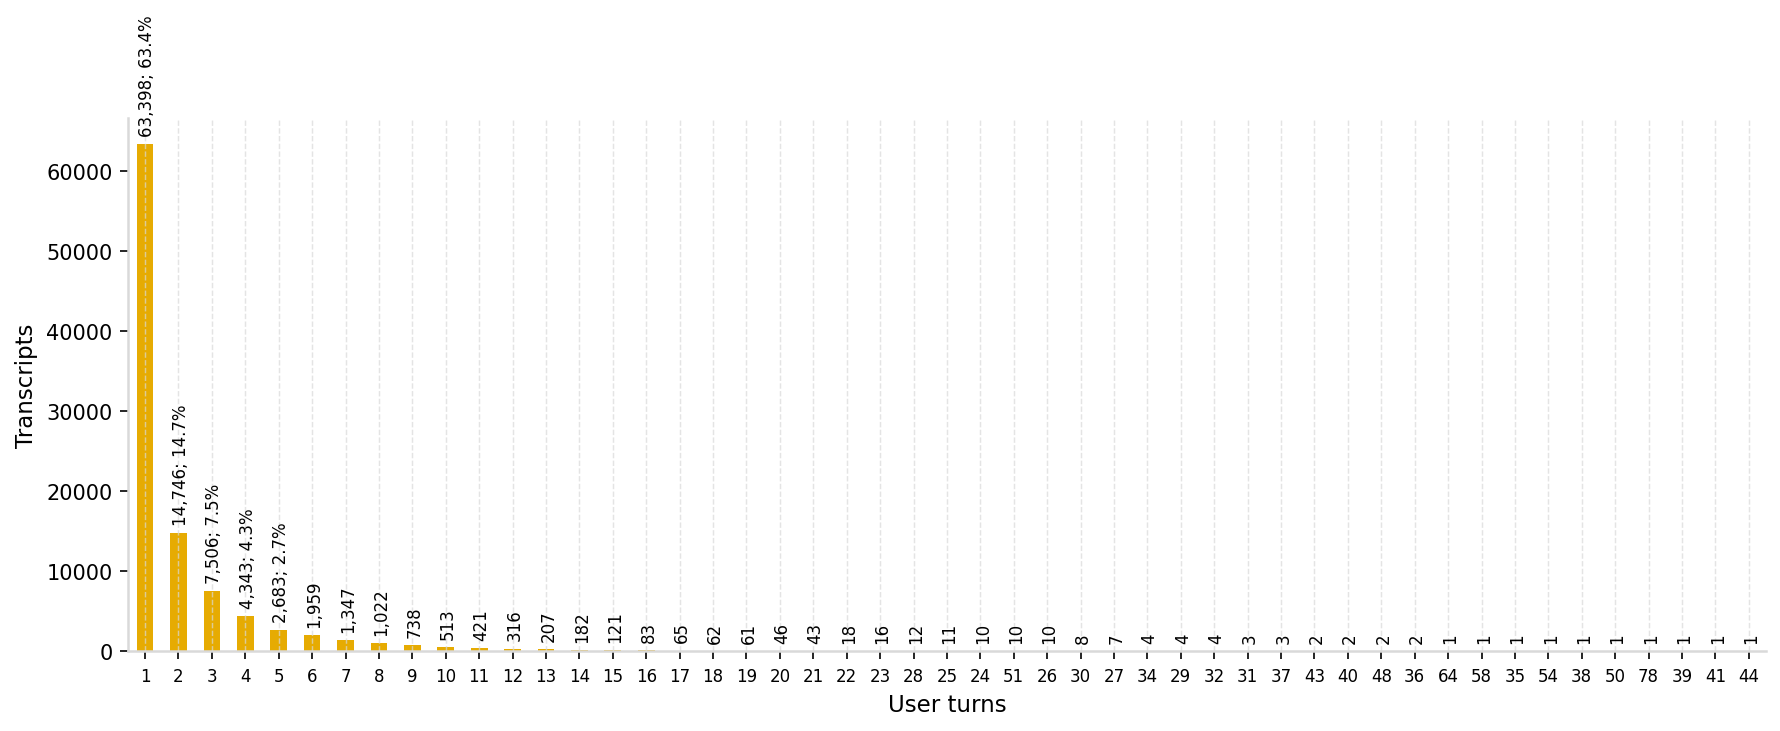

In [32]:
turn_dist_plot(df)

## Archetype distribution

In [33]:
fail_df = df[df.failure_visibility.apply(lambda x: x != "none")]

In [34]:
# Define a canonical ordering in which to display the archetypes,
# using prevalence in the main dataset as the primary factor, but
# with visible failures at the end:

all_archs = pd.Series([x for vals in fail_df.archetype_tags for x in vals])
all_archs_dist = all_archs.value_counts() 

canonical_archetype_ordering = all_archs_dist.index.tolist()
canonical_archetype_ordering.remove(visible_archetype_name)
canonical_archetype_ordering += [visible_archetype_name]
canonical_archetype_ordering = canonical_archetype_ordering[::-1]

In [35]:
def archetype_dist_plot(df, output_filename="archetypes.pdf"):
    archs = pd.Series([x for vals in df.archetype_tags for x in vals])
    dist = archs.value_counts() 

    colors = [OUR_COLOR] * (len(canonical_archetype_ordering) - 1)
    colors = ["#AAAAAA"] + colors
    
    for c in canonical_archetype_ordering:
        if c not in dist:
            dist[c] = 0.0
    ax = dist[canonical_archetype_ordering].plot.barh(figsize=(8, 4), color=colors)
    total = df.shape[0] # Total transcripts
    for patch in ax.patches:
        count = int(patch.get_width())
        pct = count / total * 100
        y_center = patch.get_y() + patch.get_height() / 2  
        x_pos = patch.get_width()
        if pct > 0.051:
            ax.text(x_pos + 1, y_center, f"{count:,}; {pct:.1f}%", va="center", fontsize=8)
        else:
            ax.text(x_pos + 1, y_center, f"{count:,}; < 0.05%", va="center", fontsize=8)
    ax.set_ylabel("")
    ax.set_xlabel("Archetype frequency")
    ax.grid(axis='y')
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

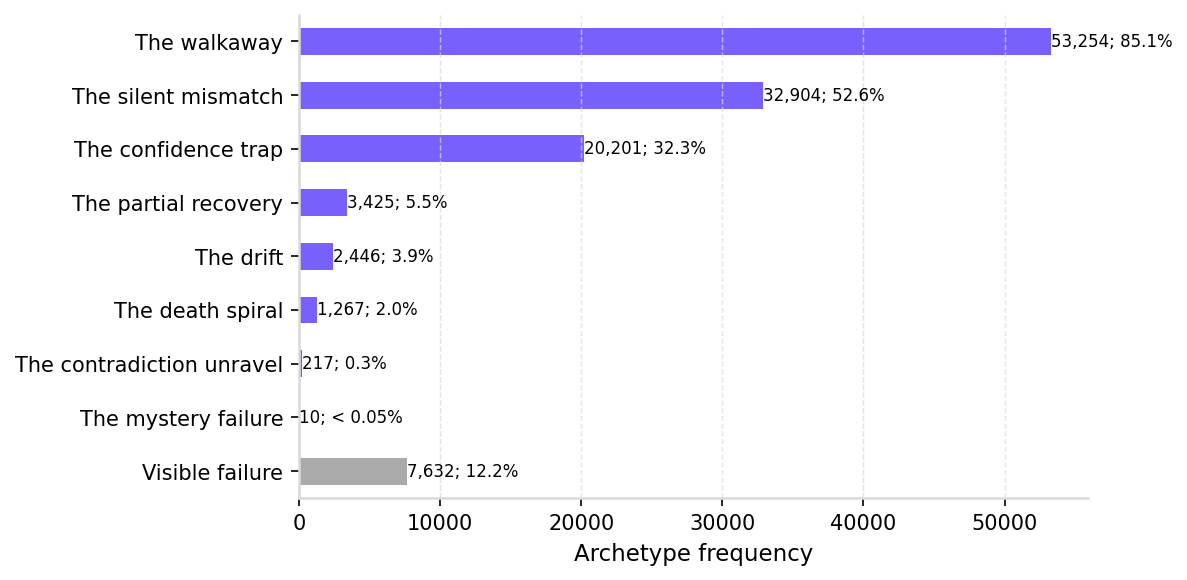

In [36]:
archetype_dist_plot(fail_df)

## Multiturn interactions

In [29]:
all_multiturn = df[df.turns == 1]

In [30]:
# Percentage of cases with exactly one turn:

all_multiturn.shape[0] / df.shape[0]

0.63398

In [31]:
multi_fail_df = fail_df[fail_df.turns > 1]

In [32]:
multi_failvisdist = multi_fail_df.failure_visibility.value_counts()
multi_failvisdist.name = "Counts"

multi_failvisdist_per = multi_failvisdist / multi_failvisdist.sum()
multi_failvisdist_per.name = "Percent"

pd.concat((multi_failvisdist, multi_failvisdist_per), axis=1).round(2)

,Counts,Percent
failure_visibility,,
invisible,12733,0.50
visible,7458,0.29
mixed,5521,0.21


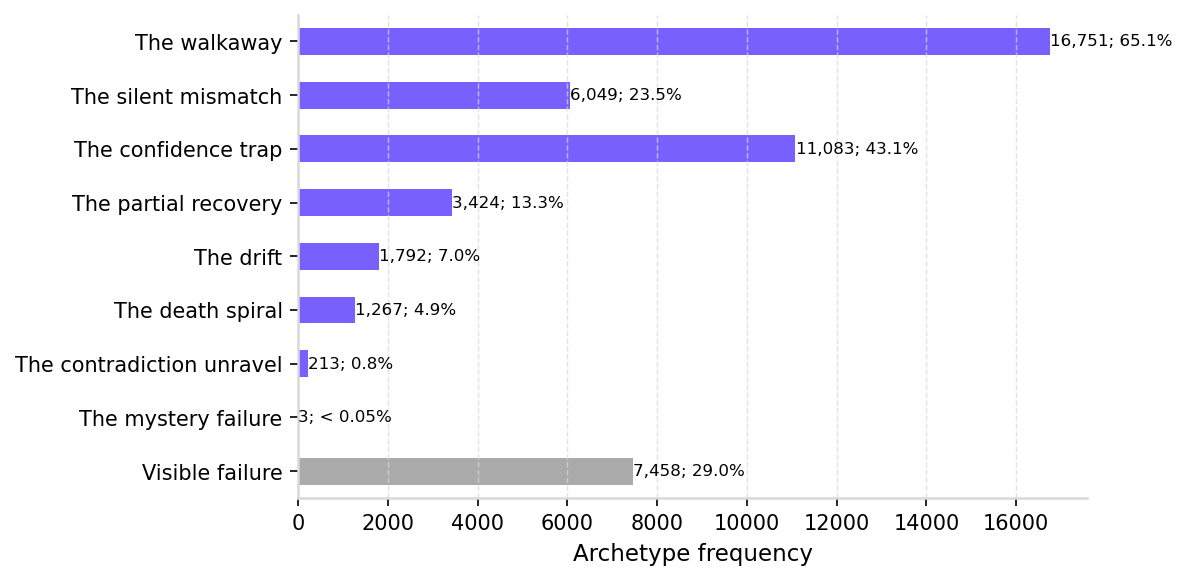

In [33]:
archetype_dist_plot(multi_fail_df, output_filename="archetypes_multiturn.pdf")

## Persistence experiments

In [34]:
def create_persist_dataset(persist_filenames, df):
    persist_dfs = []

    for modname, filename in persist_filenames.items():
        pathname = os.path.join(DATA_DIRNAME, "persist", filename)
        persist_df = analysis_utils.data_loader(pathname)
        persist_df["archetype_tags"] = persist_df.archetypes.apply(
            analysis_utils.get_archetype_tags)
        dist = persist_df.failure_visibility.value_counts()
        dist.name = modname
        persist_dfs.append((modname, persist_df, dist))

    # Get the original GPT-4 cases from WildChat:
    persist_ids = persist_dfs[1][1].conversation_id.unique().tolist()
    wc_df = df[df.index.isin(persist_ids)]
    wc_dist = wc_df.failure_visibility.value_counts()
    wc_dist.name = "GPT-3.5/4 (WildChat original)"
    main_item = ("GPT-3.5/4 (WildChat original)", wc_df, wc_dist)
    persist_dfs = [main_item] + persist_dfs
    return persist_dfs

In [35]:
persist_filenames = {        
    "GPT 4.1":    "persist2_gpt41_quality_C_opus.jsonl.gz",
    "Sonnet 4.6": "persist2_sonnet_quality_C_opus.jsonl.gz",       
    "Opus 4.6":   "persist2_opus_quality_C_opus.jsonl.gz",
    "GPT 5.4":    "persist2_gpt5_quality_C_opus.jsonl.gz"
}

In [36]:
persist_dfs = create_persist_dataset(persist_filenames, df)

In [37]:
persist_fails = pd.concat([x[2] for x in persist_dfs], axis=1).fillna(0)

In [38]:
def persistence_plot(data, output_filename="failure-persist.pdf"):
    colors = [
        "#E7298A", # 5.4 
        "#D95F02", # Opus
        "#E6AB02", # Sonnet      
        "#5CAD70", # 4.1                   
        "#7760FB" # WildChat
    ][::-1] # Backwards because matplotlib is always backwards.

    data = data.loc[["none", "visible", "mixed", "invisible"]]
    ax = data.plot.barh(figsize=(6, 5), color=colors, edgecolor='black')                        
    per = data.apply(lambda x: x / x.sum(), axis=0)

    labels = []
    for i in data.index:
        for j in data.columns:
            labels.append((i, j))
            
    for i, (patch, (row, col)) in enumerate(zip(ax.patches, labels)):
        count = int(patch.get_width())
        total = data[col].sum()
        pct = count / total * 100
        y_center = patch.get_y() + patch.get_height() / 2  
        x_pos = patch.get_width()
        if count > 0:
            ax.text(x_pos + 1, y_center, f"{pct:.1f}%", va="center", fontsize=8)
    ax.set_xlabel("Transcripts")
    ax.set_ylabel("")
    ax.grid(axis='y')
    ax.legend(reverse=True)
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

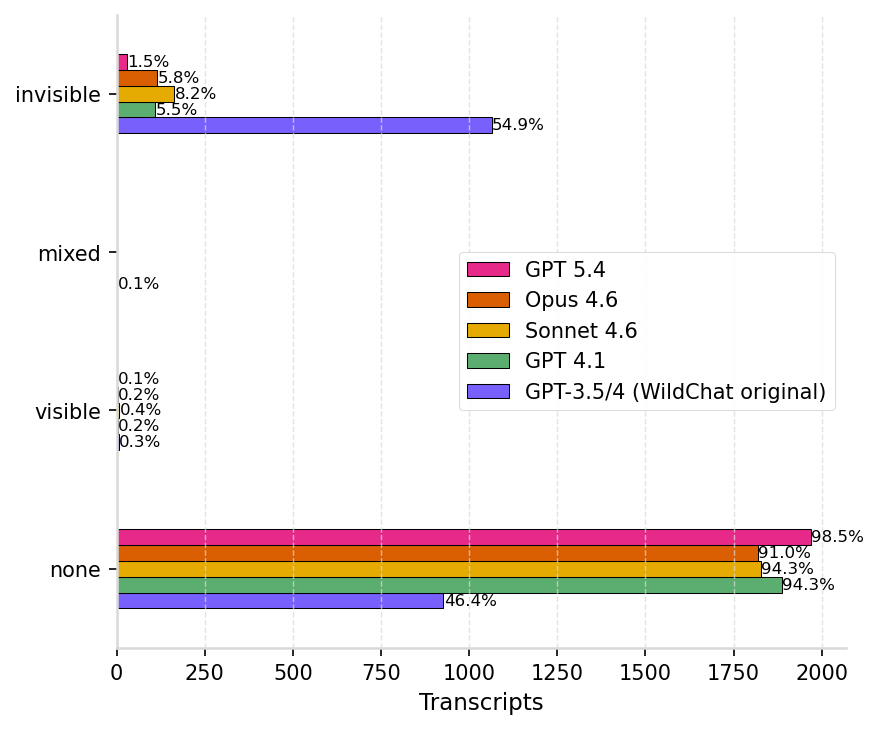

In [39]:
persistence_plot(persist_fails)

In [40]:
def archetype_dist_compare_plot(dfs, output_filename="archetypes-persist-compare.pdf"):
    colors = [
        "#E7298A", # 5.4 
        "#D95F02", # Opus
        "#E6AB02", # Sonnet      
        "#5CAD70", # 4.1                   
        "#7760FB" # WildChat
    ][::-1] # Backwards because matplotlib is always backwards.

    archs = []
    allcounts = []
    for label, df, _ in dfs:    
        df = df[df.failure_visibility != "none"]
        vals = pd.Series([x for vals in df.archetype_tags for x in vals])
        counts = vals.value_counts()
        counts.name = label
        for c in canonical_archetype_ordering:
            if c not in counts:
                counts[c] = 0.0
        dist = counts / counts.sum()
        archs.append(dist)
        allcounts.append(counts)
        
    archs = pd.concat(archs, axis=1)
    allcounts = pd.concat(allcounts, axis=1)
    archs = archs.loc[canonical_archetype_ordering]
    ax = archs.plot.barh(color=colors, figsize=(8, 6), edgecolor='black')

    all_labels = []
    for j in archs.columns:
        for i in archs.index:        
            all_labels.append((i, j))

    for patch, (row, col) in zip(ax.patches, all_labels):
        pct = patch.get_width() * 100
        count = int(allcounts.loc[row, col])
        y_center = patch.get_y() + patch.get_height() / 2  
        x_pos = patch.get_width()
        if count > 0:
            ax.text(x_pos, y_center, f"{count:,}", va="center", fontsize=6)
    
    ax.legend(reverse=True, loc="lower right")
    ax.set_ylabel("")
    ax.set_xlabel("Percentage of invisible failures")
    ax.grid(axis='y')
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

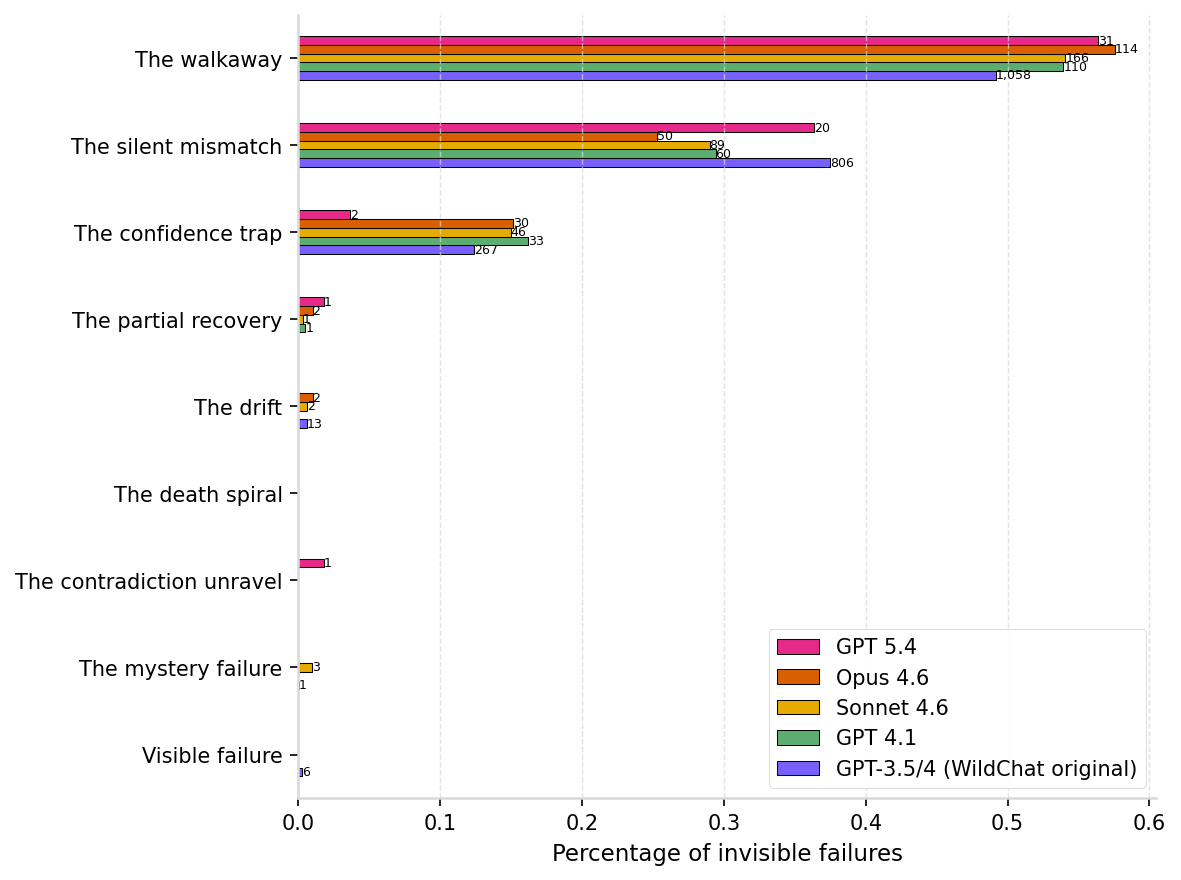

In [41]:
archetype_dist_compare_plot(persist_dfs)

## Archetype co-occurrence

In [42]:
def archetype_xtab(df):
    data = []
    for archs in df.archetype_tags:
        for i in range(len(archs)):
            for j in range(len(archs)):
                if i != j:
                    data.append({"archetype1": archs[i], "archetype2": archs[j]})
    data = pd.DataFrame(data)
    xtab = pd.crosstab(data.archetype1, data.archetype2)
    return xtab

In [43]:
arch_cooccur = archetype_xtab(fail_df)

arch_cooccur_pmi = analysis_utils.pmi(arch_cooccur, positive=True)

arch_cooccur_prob = (arch_cooccur.T / arch_cooccur.sum(axis=1)).T

In [44]:
def archetype_cooccur_plot(xtab, typ="ppmi"):
    canon = [d for d in canonical_archetype_ordering if d in xtab.columns]
    xtab = xtab.loc[canon[::-1], canon[::-1]]
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        xtab, 
        cmap="Purples",
        linewidths=0.5, 
        ax=ax,
        annot=True, 
        fmt=".2f",
        cbar_kws={"label": "PPMI"})
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    output_filename = f"archetype_cooccur_{typ}.pdf"
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

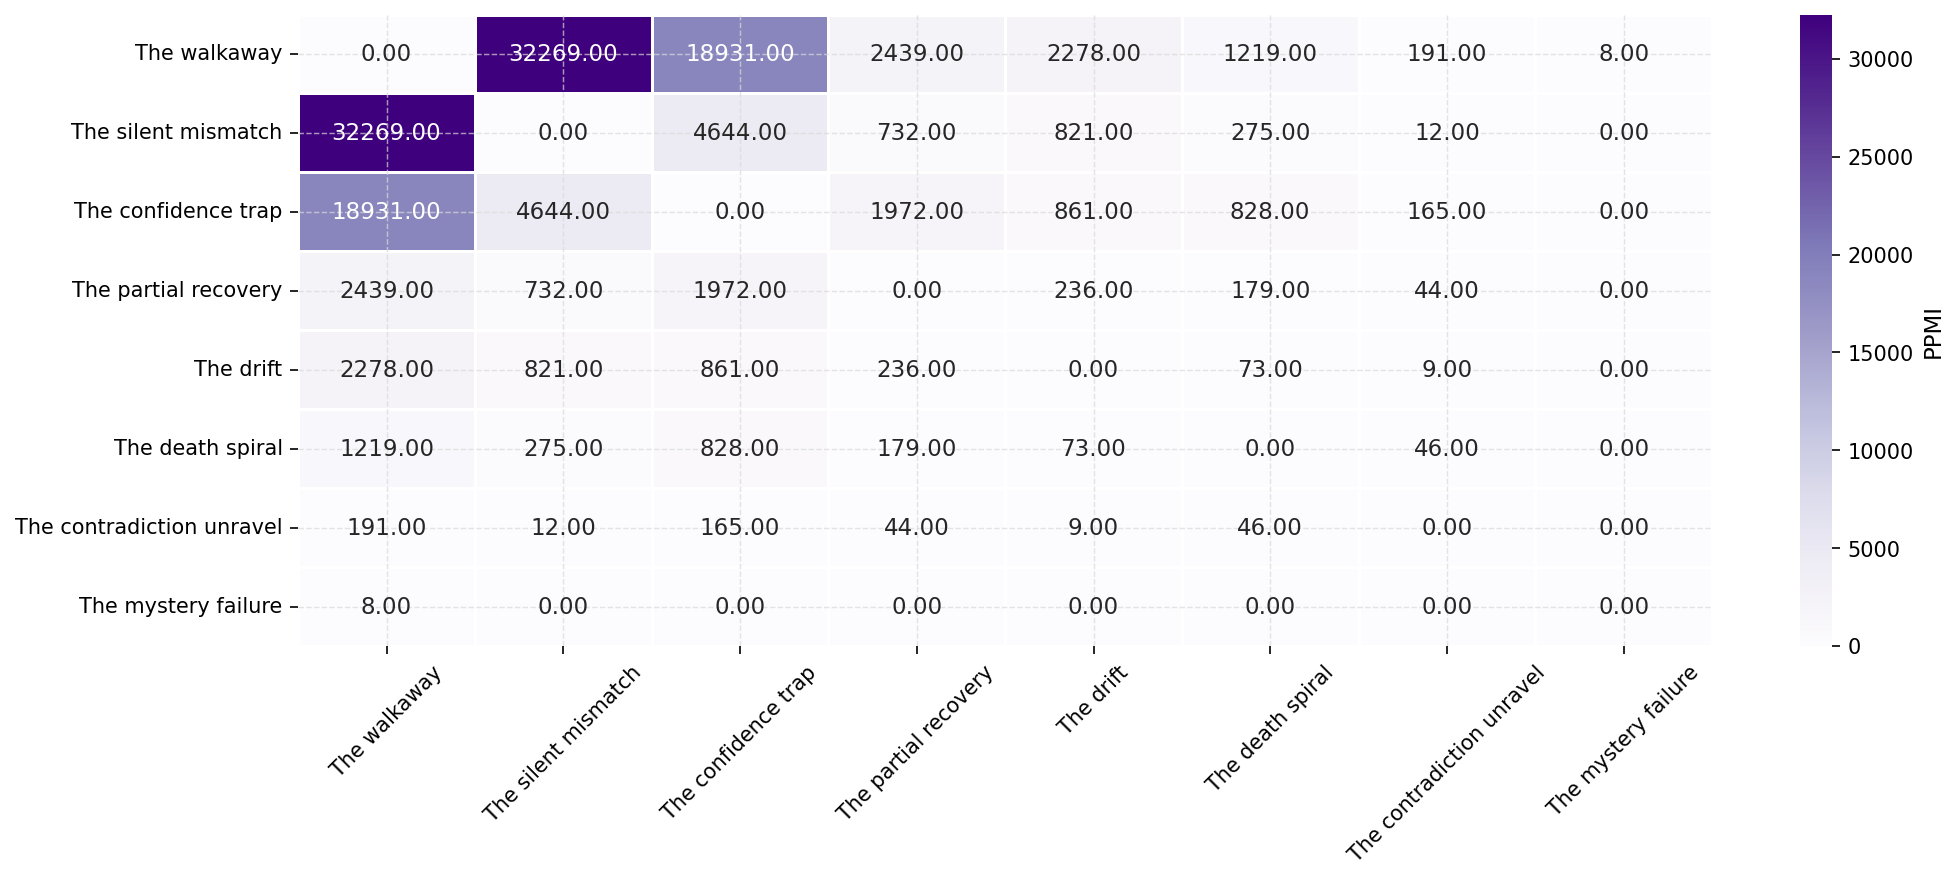

In [45]:
archetype_cooccur_plot(arch_cooccur, typ="count")

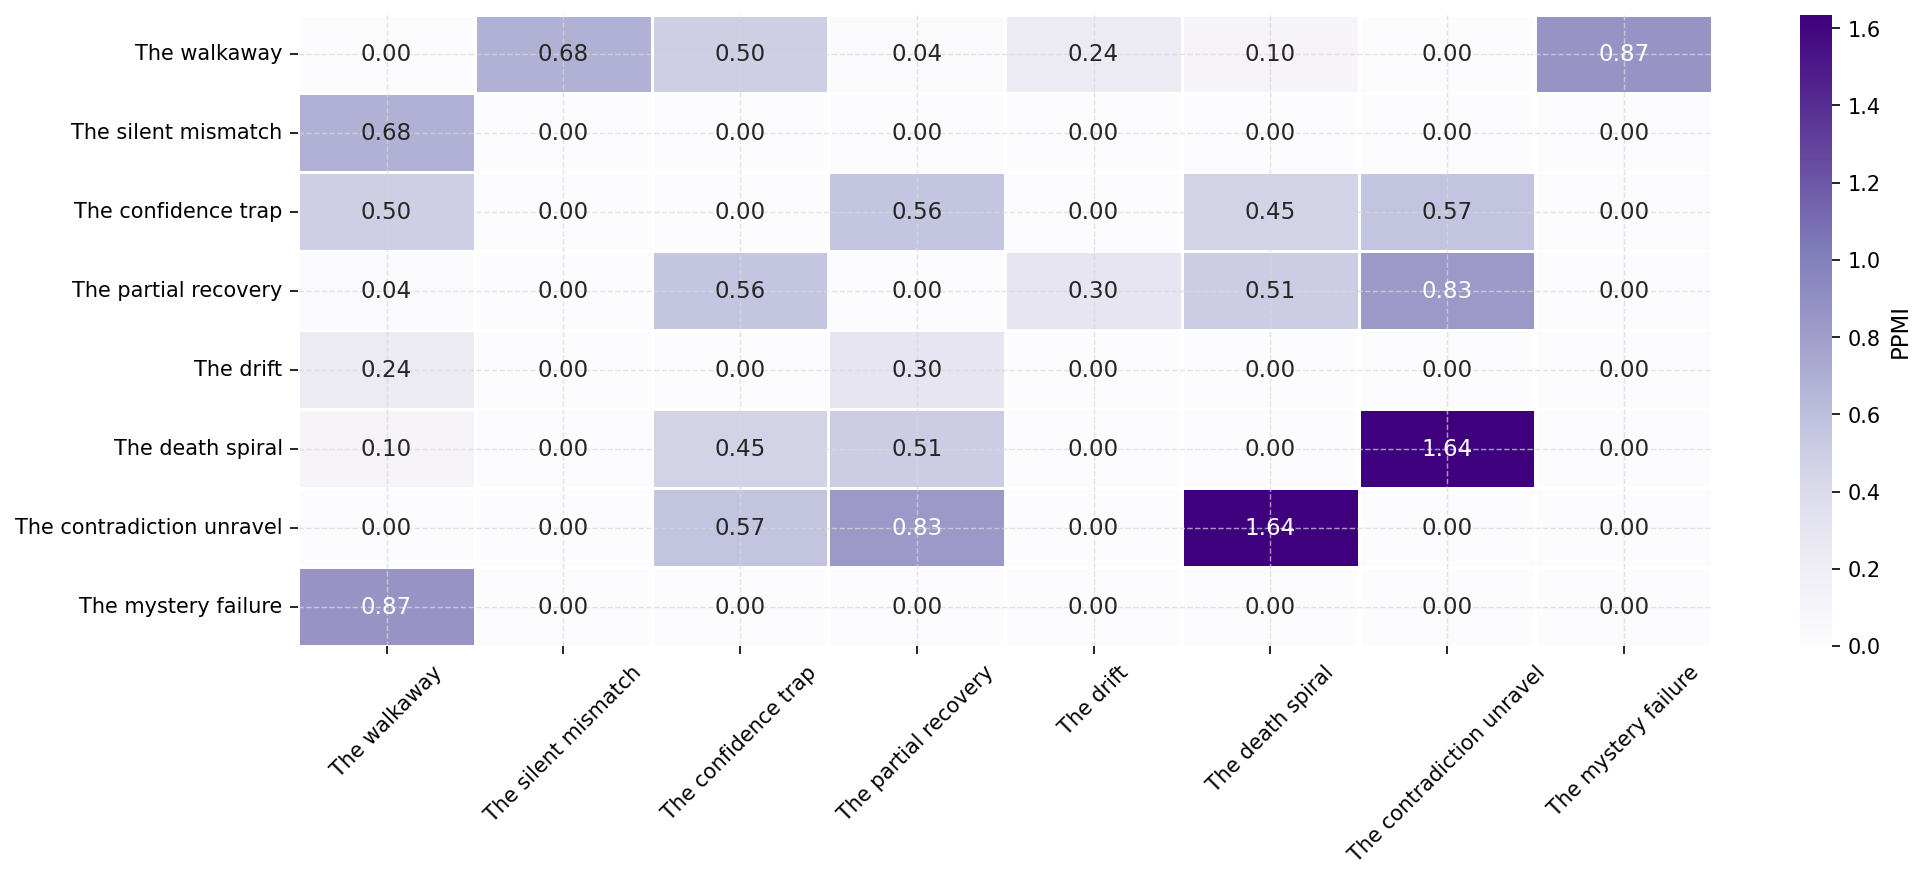

In [46]:
archetype_cooccur_plot(arch_cooccur_pmi, typ="ppmi")

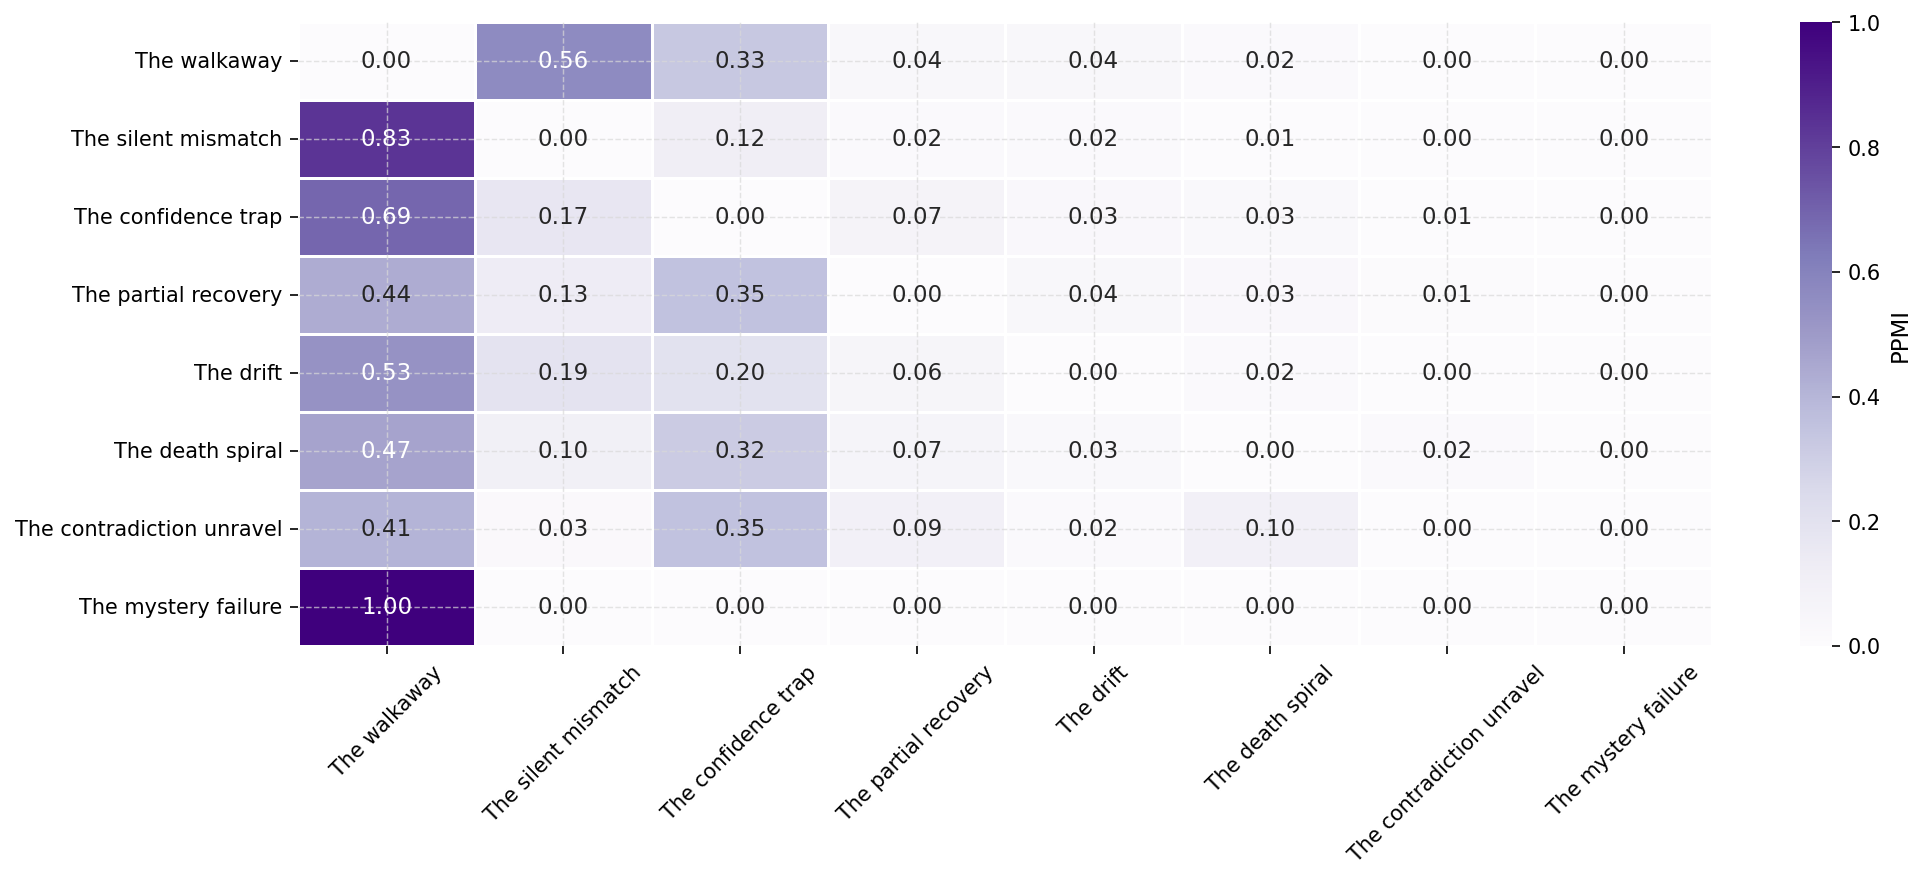

In [47]:
archetype_cooccur_plot(arch_cooccur_prob, typ="prob")

## Domains and archetypes

In [48]:
most_frequent_domains = df.primary_vertical.value_counts().iloc[: 10].index.tolist()

In [49]:
most_frequent_domains

['creative_writing',
 'design_ux',
 'software_development',
 'education_academic',
 'general_knowledge',
 'content_production',
 'personal_lifestyle',
 'translation_language',
 'gaming',
 'it_infrastructure']

In [50]:
def domain_archetype_xtab(df):
    data = []
    for _, row in df.iterrows():
        for a in row.archetype_tags:
            data.append({
                'primary_vertical': row['primary_vertical'], 
                'archetype': a
            })  
    data = pd.DataFrame(data)
    xtab = pd.crosstab(data.primary_vertical, data.archetype)
    return xtab

In [51]:
da_xtab = domain_archetype_xtab(fail_df)

In [52]:
da_prob = (da_xtab.T / da_xtab.sum(axis=1)).T

In [53]:
da_pmi = analysis_utils.pmi(da_xtab, positive=True)

In [54]:
def domain_archetype_plot(X, typ="ppmi"):
    heatmap_data = X.loc[
        most_frequent_domains, 
        canonical_archetype_ordering[::-1]
    ]
    if typ == "ppmi":
        ylabel = "PPMI"
    elif typ == "prob":
        ylabel = "P(archetype | domain)"
    elif typ == "count":
        ylabel = "Co-occurrences"
    else:
        raise ValueError(f"typ value {typ} not recognised")        
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap="Blues", annot=True,
                fmt=".2f",
                linewidths=0.5, ax=ax,
                cbar_kws={"label": ylabel})
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    output_filename = f"archetype_domain_{typ}.pdf"
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

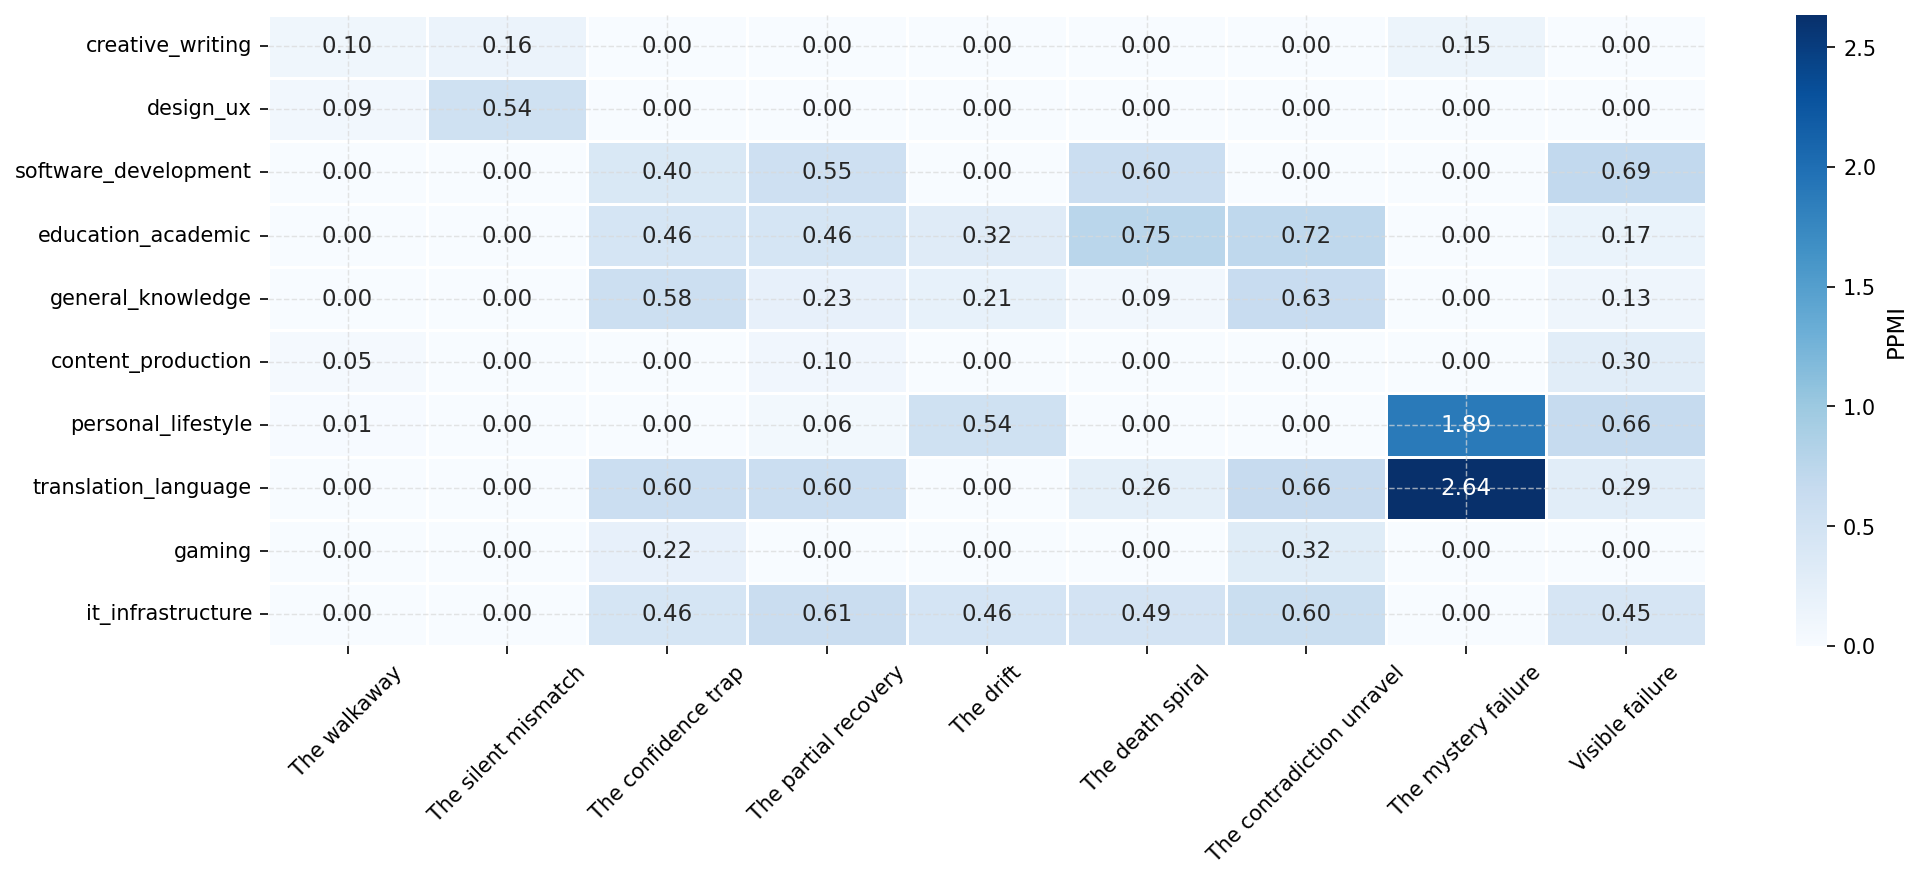

In [55]:
domain_archetype_plot(da_pmi)

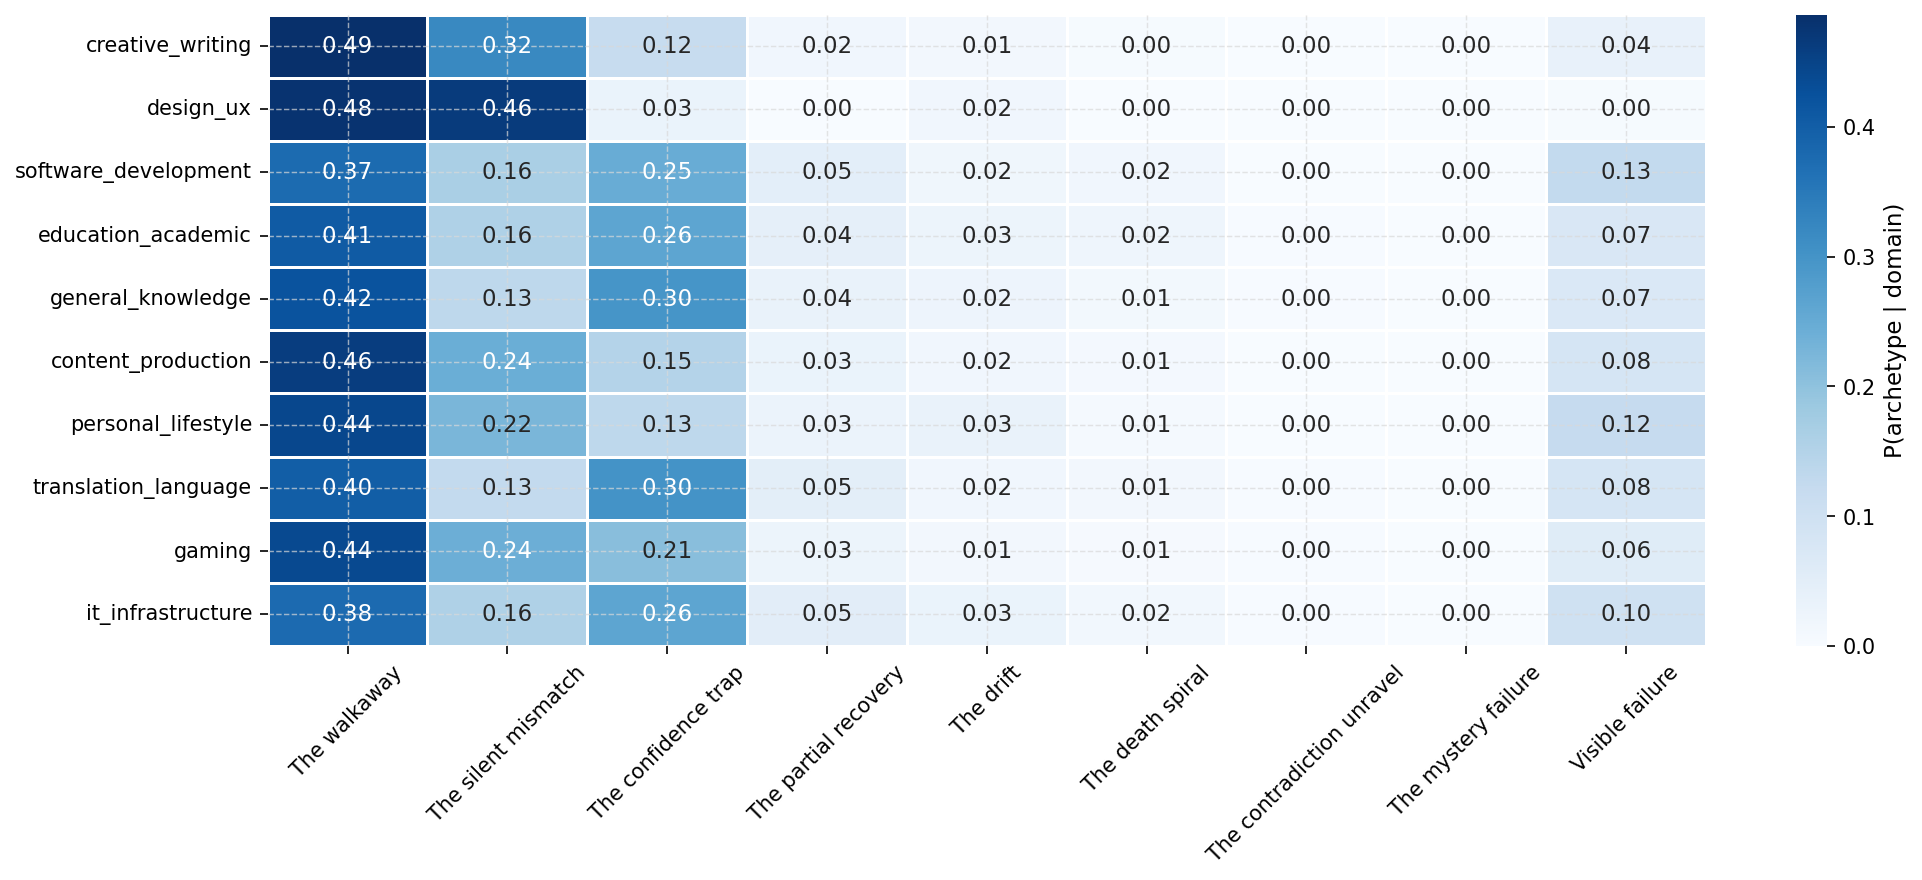

In [56]:
domain_archetype_plot(da_prob, "prob")

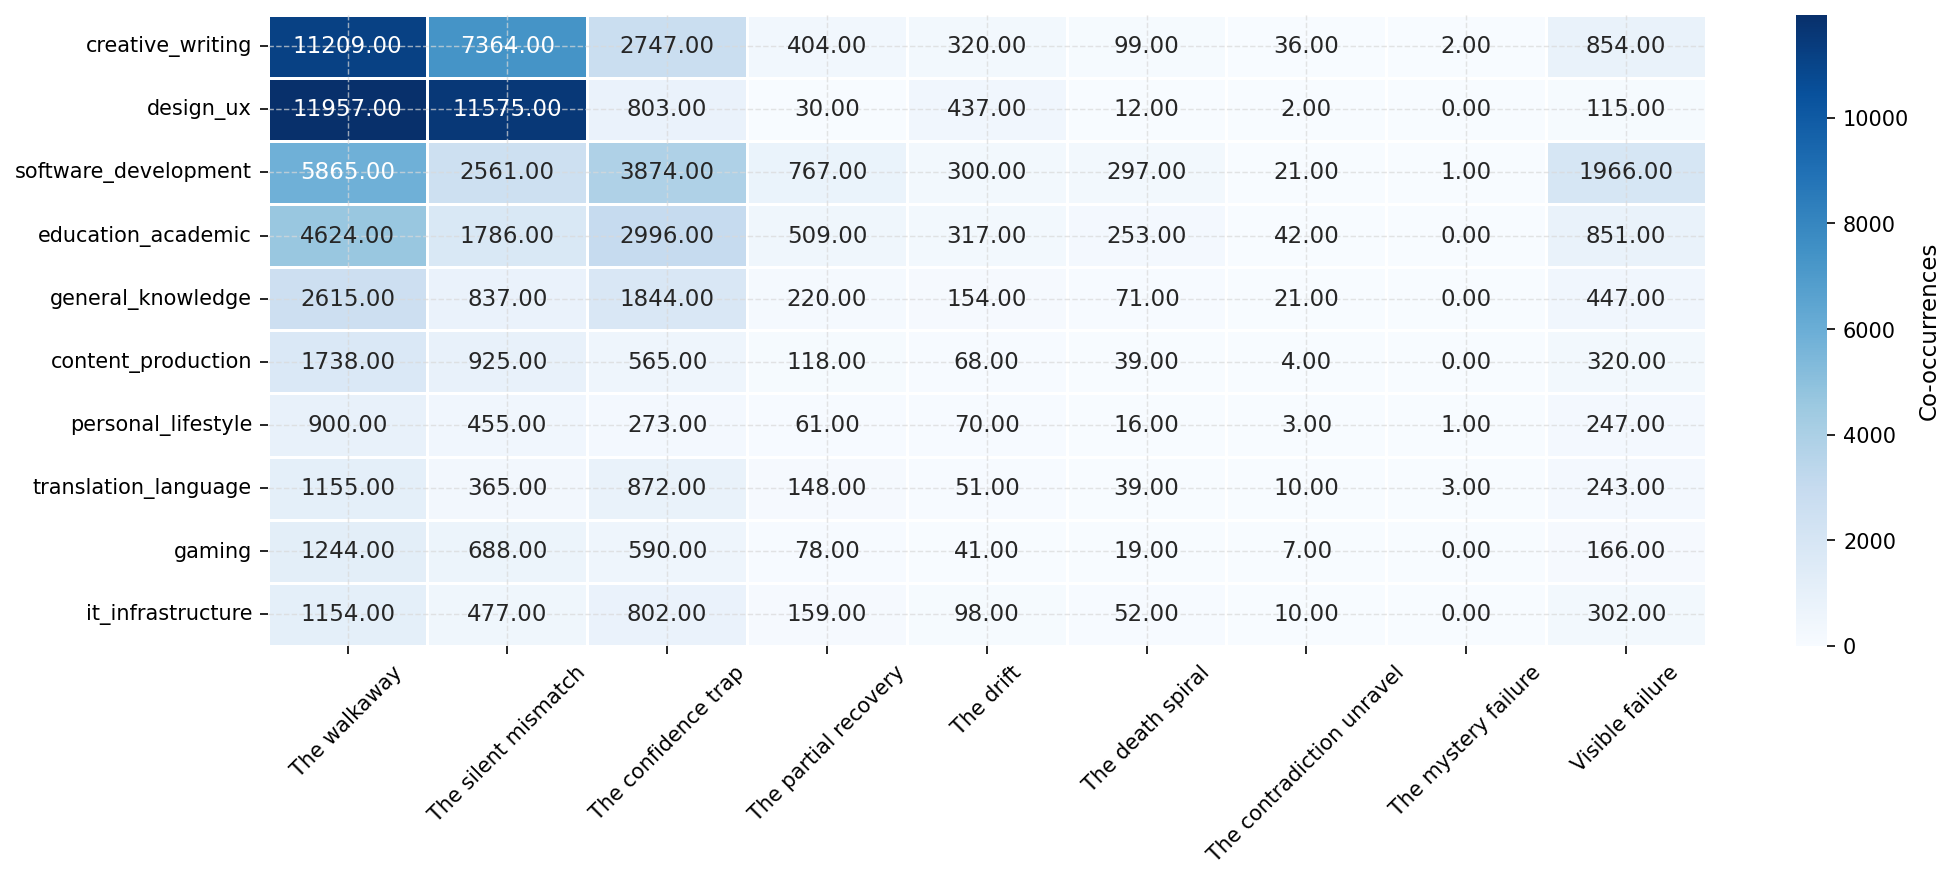

In [57]:
domain_archetype_plot(da_xtab, "count")

## Annotation agreement

### Failures

In [58]:
condnames = {
    "A": "Transcript-only",
    "B": "Signals + Transcript",
    "C": "Signals-only"    
}

for cond in ("A", "B", "C"):    
    print("=" * 70)
    print(condnames[cond])
    analysis_utils.failure_agreement_report(condition=cond)

Transcript-only
\begin{tabular}{lrr}
\toprule
label & kappa & Agreement \\
\midrule
invisible & 0.46 & 0.75 \\
mixed & 0.43 & 0.95 \\
none & 0.42 & 0.78 \\
visible & 0.54 & 0.95 \\
Macro & 0.46 & 0.86 \\
Overall & 0.62 & 0.86 \\
\bottomrule
\end{tabular}

Signals + Transcript
\begin{tabular}{lrr}
\toprule
label & kappa & Agreement \\
\midrule
invisible & 0.70 & 0.85 \\
mixed & 0.53 & 0.96 \\
none & 0.73 & 0.88 \\
visible & 0.55 & 0.96 \\
Macro & 0.63 & 0.91 \\
Overall & 0.77 & 0.91 \\
\bottomrule
\end{tabular}

Signals-only
\begin{tabular}{lrr}
\toprule
label & kappa & Agreement \\
\midrule
invisible & 0.83 & 0.91 \\
mixed & 0.63 & 0.96 \\
none & 0.85 & 0.93 \\
visible & 0.67 & 0.96 \\
Macro & 0.74 & 0.94 \\
Overall & 0.84 & 0.94 \\
\bottomrule
\end{tabular}



### Archetypes

In [59]:
for condition in ("A", "B", "C"):    
    print("=" * 70)
    print(condnames[condition])

    dirname = os.path.join(DATA_DIRNAME, "interannotator")
    
    opus = analysis_utils.data_loader(f"{dirname}/score_10k_quality_{condition}_opus.jsonl.gz")       
    gpt = analysis_utils.data_loader(f"{dirname}/score_10k_quality_{condition}_gpt5.jsonl.gz")
    
    analysis_utils.archetype_agreement_report(opus, gpt, colname="archetype_tags")

Transcript-only
\begin{tabular}{lrr}
\toprule
label & kappa & Agreement \\
\midrule
The confidence trap & 0.51 & 0.80 \\
The contradiction unravel & 0.49 & 0.99 \\
The death spiral & 0.68 & 0.98 \\
The drift & 0.28 & 0.93 \\
The mystery failure & 0.44 & 0.81 \\
The partial recovery & 0.28 & 0.86 \\
The silent mismatch & 0.50 & 0.75 \\
The visible & 0.00 & 1.00 \\
The walkaway & 0.16 & 0.49 \\
Macro & 0.37 & 0.84 \\
Micro & 0.52 & 0.84 \\
\bottomrule
\end{tabular}

Signals + Transcript
\begin{tabular}{lrr}
\toprule
label & kappa & Agreement \\
\midrule
The confidence trap & 0.70 & 0.88 \\
The contradiction unravel & 0.65 & 0.99 \\
The death spiral & 0.77 & 0.98 \\
The drift & 0.32 & 0.93 \\
The mystery failure & 0.73 & 0.89 \\
The partial recovery & 0.28 & 0.83 \\
The silent mismatch & 0.60 & 0.80 \\
The under delivered & 0.00 & 1.00 \\
The walkaway & 0.59 & 0.79 \\
Macro & 0.52 & 0.90 \\
Micro & 0.68 & 0.90 \\
\bottomrule
\end{tabular}

Signals-only
\begin{tabular}{lrr}
\toprule
label 

### Signals

In [60]:
opus_signal_df = analysis_utils.data_loader(
    os.path.join(DATA_DIRNAME, "interannotator", "score_10k_opus_calibrated_transcripts.jsonl.gz"))

In [61]:
gpt_signal_df = analysis_utils.data_loader(
    os.path.join(DATA_DIRNAME, "interannotator", "score_10k_gpt5_calibrated_transcripts.jsonl.gz"))

In [62]:
opus_signal_df["ai_signals"] = opus_signal_df.ai_signal_summary.apply(lambda x: list(x.keys()))

In [63]:
gpt_signal_df["ai_signals"] = gpt_signal_df.ai_signal_summary.apply(lambda x: list(x.keys()))

In [64]:
# Unique signals:

pd.Series([x for vals in opus_signal_df.ai_signals for x in vals]).unique().shape

(50,)

In [65]:
opus_signal_df["user_signals"] = opus_signal_df.user_signal_summary.apply(lambda x: list(x.keys()))

In [66]:
gpt_signal_df["user_signals"] = gpt_signal_df.user_signal_summary.apply(lambda x: list(x.keys()))

In [67]:
pd.Series([x for vals in opus_signal_df.user_signals for x in vals]).unique().shape

(13,)

In [68]:
analysis_utils.archetype_agreement_report(opus_signal_df, gpt_signal_df, "ai_signals")

\begin{tabular}{lrr}
\toprule
label & kappa & Agreement \\
\midrule
adaptation & 0.71 & 0.94 \\
ai_acknowledges_correction & 0.81 & 0.98 \\
ai_asked_clarifying_question & 0.70 & 0.98 \\
ai_asked_probing_question & 0.59 & 1.00 \\
ai_asks_for_feedback & 0.09 & 1.00 \\
ai_asserts_knowledge_limit & 0.72 & 0.95 \\
ai_cites_source & 0.59 & 0.97 \\
ai_empathy_expressed & 0.38 & 0.99 \\
ai_flags_complexity & 0.60 & 0.96 \\
ai_hedges_uncertainty & 0.57 & 0.92 \\
ai_implicit_refusal & 0.16 & 0.92 \\
ai_malfunction & 0.78 & 0.99 \\
ai_normalizes_difficulty & 0.57 & 0.99 \\
ai_offered_options & 0.41 & 0.97 \\
ai_offers_to_elaborate & 0.48 & 0.96 \\
ai_provides_alternatives & 0.43 & 0.90 \\
ai_provides_caveats & 0.71 & 0.92 \\
ai_provides_example & 0.53 & 0.89 \\
ai_provides_step_by_step & 0.72 & 0.93 \\
ai_references_prior_turn & 0.53 & 0.91 \\
ai_references_user_words & 0.26 & 0.94 \\
ai_refuses_or_declines & 0.76 & 0.98 \\
ai_self_contradiction & 0.10 & 0.98 \\
ai_stated_interpretation & 0.22 & 

In [69]:
analysis_utils.archetype_agreement_report(opus_signal_df, gpt_signal_df, "user_signals")

\begin{tabular}{lrr}
\toprule
label & kappa & Agreement \\
\midrule
user_abandons_thread & 0.72 & 0.96 \\
user_ambiguous_request & 0.52 & 0.81 \\
user_asks_clarification & 0.60 & 0.97 \\
user_corrects_ai & 0.70 & 0.98 \\
user_expresses_dissatisfaction & 0.61 & 0.98 \\
user_expresses_frustration & 0.60 & 0.99 \\
user_implicit_correction & 0.67 & 0.94 \\
user_multi_request & 0.50 & 0.81 \\
user_positive_feedback & 0.81 & 1.00 \\
user_provides_invalid_input & 0.41 & 0.96 \\
user_repeats_request & 0.61 & 0.96 \\
user_scope_change & 0.32 & 0.94 \\
user_validation_seeking & 0.46 & 0.97 \\
Macro & 0.58 & 0.94 \\
Micro & 0.59 & 0.94 \\
\bottomrule
\end{tabular}



## Newer 4o dataset

In [73]:
newer_df = pd.read_json(
    os.path.join(DATA_DIRNAME, "wildchat4M_4o_annotations_opus_v2.json.gz")
).set_index('conversation_id')

In [74]:
newer_df["archetype_tags"] = newer_df.archetypes.apply(analysis_utils.get_archetype_tags)

In [75]:
newer_df["archetype_tags"] = newer_df.apply(
    lambda row: [visible_archetype_name] if row.failure_visibility == "visible" else row.archetype_tags, 
    axis=1)

### 4o archetype distribution

In [76]:
newer_fail_df = newer_df[newer_df.failure_visibility != "none"]

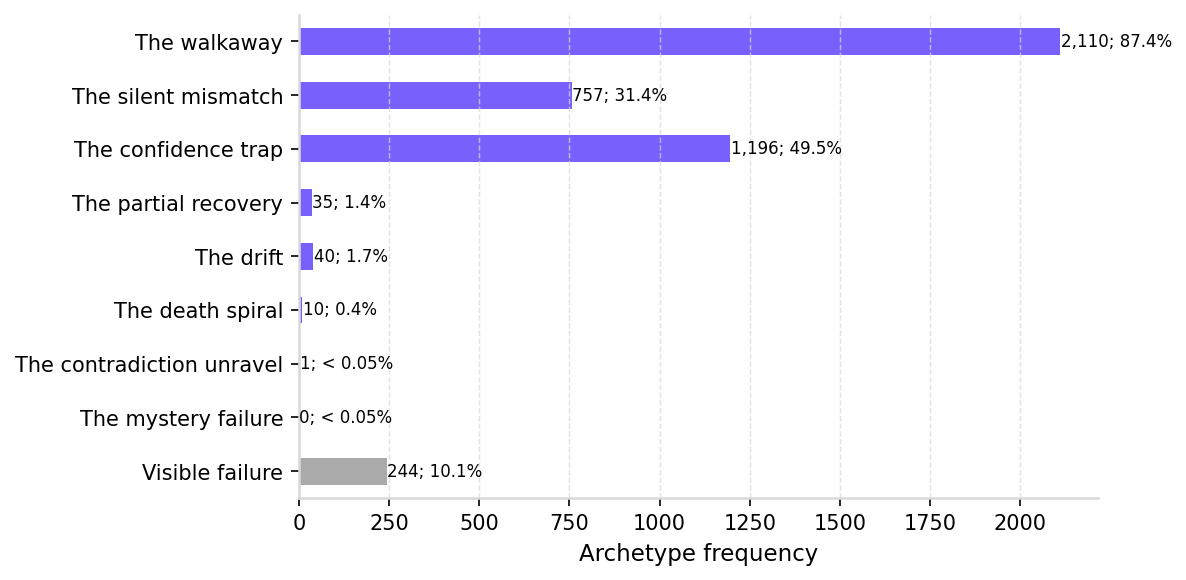

In [77]:
archetype_dist_plot(newer_fail_df, "archetypes-4o.pdf")

### 4o failure distribution

In [78]:
newer_visdist = newer_df.failure_visibility.value_counts()

In [79]:
newer_visdist

failure_visibility
none         7586
invisible    2105
visible       244
mixed          65
Name: count, dtype: int64

In [81]:
# Percentage of failures

newer_fail_df.shape[0] / newer_df.shape[0]

0.2414

In [83]:
# Percentage of failures that are invisible:

newer_failvisdist = newer_fail_df.failure_visibility.value_counts()
newer_failvisdist.name = "Counts"

newwer_failvisdist_per = newer_failvisdist / newer_failvisdist.sum()
newwer_failvisdist_per.name = "Percent"

pd.concat((newer_failvisdist, newwer_failvisdist_per), axis=1).round(2)

,Counts,Percent
failure_visibility,,
invisible,2105,0.87
visible,244,0.10
mixed,65,0.03
